In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score, silhouette_score

sns.set_theme(style='ticks', palette='Set2')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

## visualize the batch effect and the perturbation effect

load datasets by the model trained on HEK293FT

In [5]:
ad_id = sc.concat([
    sc.read_h5ad(f'../results/kowalski/hek293ft_noisy-seed42/anndata/preprocessed_noisy_HEK293FT_R1_true_agg.h5ad'),
    sc.read_h5ad(f'../results/kowalski/hek293ft_noisy-seed42/anndata/preprocessed_noisy_HEK293FT_R2_true_agg.h5ad')
])
ad_ood = sc.read_h5ad(f'../results/kowalski/hek293ft_whole_noisy-seed42/anndata/preprocessed_noisy_K562_true.h5ad')
ad_id = ad_id[~ad_id.obs['perturbation'].isin(['control', 'neg'])]
ad_ood = ad_ood[~ad_ood.obs['perturbation'].isin(['control', 'neg'])]

In [6]:
# overview of cell line and batch
ad = sc.concat({
    'ID': ad_id, 
    'OOD': ad_ood
}, label='Group')
sc.pp.sample(ad, fraction=1)
sc.pp.pca(ad)
sc.pp.neighbors(ad)
sc.tl.umap(ad, random_state=42)

In [7]:
ad.obs['shuffled'] = ad.obs[['perturbation', 'perturbation_true']].apply(
    lambda x: x['perturbation'] != x['perturbation_true'], axis=1
)

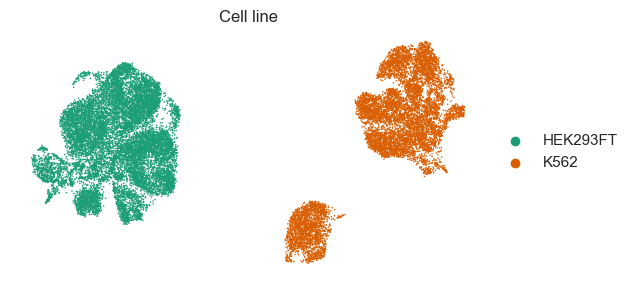

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3))
sc.pl.umap(
    ad, color='cellline', frameon=False, ax=ax, show=False,
    palette=sns.color_palette('Dark2'),
    title='Cell line'
)
if ax.collections:
    ax.collections[0].set_rasterized(True)
plt.tight_layout()
plt.savefig('../figures/5_kowalski_noisy_umap_overview.pdf', bbox_inches='tight', dpi=600)
plt.show()

In [9]:
# ID setting
pert_id = ad[ad.obs['Group'] == 'ID'].copy()
order = sorted(pert_id.obs['perturbation'].unique())
pert_id.obs['perturbation'] = pd.Categorical(pert_id.obs['perturbation'], categories=order, ordered=True)
shift_id = sc.AnnData(
    X=pert_id.obsm['shift'],
    obs=pert_id.obs,
    obsm={'proba': pert_id.obsm['proba']},
    var=pd.DataFrame(index=[f's{i}' for i in range(pert_id.obsm['shift'].shape[1])])
)
sc.pp.pca(shift_id)
sc.pp.neighbors(shift_id)
sc.tl.umap(shift_id)

In [10]:
pert_id.obs['shuffled'] = pert_id.obs['perturbation'].astype(str) != pert_id.obs['perturbation_true'].astype(str)
shift_id.obs['shuffled'] = shift_id.obs['perturbation'].astype(str) != shift_id.obs['perturbation_true'].astype(str)

In [11]:
## calulate cluster quality with true labels under different clustering resolutions
def calculate_cluster_quality(ad, resolutions=[0.5, 1, 2, 3, 4], labels=['replicate', 'perturbation', 'perturbation_true']):
    metric_list = []
    for res in resolutions:
        if f'leiden_{res}' not in ad.obs.columns:
            sc.tl.leiden(ad, key_added=f'leiden_{res}', resolution=res, flavor='igraph', n_iterations=2)
        leiden_labels = ad.obs[f'leiden_{res}']
        for label in labels:
            true_labels = ad.obs[label]
            metric_list.append({
                'resolution': res,
                'label': label,
                'ARI': adjusted_rand_score(true_labels, leiden_labels),
                'NMI': normalized_mutual_info_score(true_labels, leiden_labels),
                'AMI': adjusted_mutual_info_score(true_labels, leiden_labels),
            })
    return pd.DataFrame(metric_list)

In [12]:
cluster_quality_id = pd.concat([
    calculate_cluster_quality(pert_id).assign(embedding='Original Expression'), 
    calculate_cluster_quality(shift_id).assign(embedding='Estimated Shifting')
])

In [13]:
cluster_quality_id['type'] = cluster_quality_id['label'].map({
    'replicate': 'originally given',
    'perturbation': 'partial shuffled',
    'perturbation_true': 'originally given'
})
cluster_quality_id['label'] = cluster_quality_id['label'].map({
    'replicate': 'replicate',
    'perturbation': 'perturbation',
    'perturbation_true': 'perturbation'
})
cluster_quality_id

,resolution,label,ARI,NMI,AMI,embedding,type
0,0.5,replicate,0.143087,0.238858,0.238634,Original Expression,originally given
1,0.5,perturbation,0.106676,0.297700,0.294045,Original Expression,partial shuffled
2,0.5,perturbation,0.132207,0.370694,0.367423,Original Expression,originally given
3,1.0,replicate,0.124247,0.227058,0.226805,Original Expression,originally given
4,1.0,perturbation,0.113681,0.295697,0.291538,Original Expression,partial shuffled
5,1.0,perturbation,0.141022,0.367781,0.364052,Original Expression,originally given
6,2.0,replicate,0.070749,0.210081,0.209731,Original Expression,originally given
7,2.0,perturbation,0.108039,0.278816,0.272570,Original Expression,partial shuffled
8,2.0,perturbation,0.134046,0.346368,0.340714,Original Expression,originally given
9,3.0,replicate,0.043738,0.196690,0.196187,Original Expression,originally given


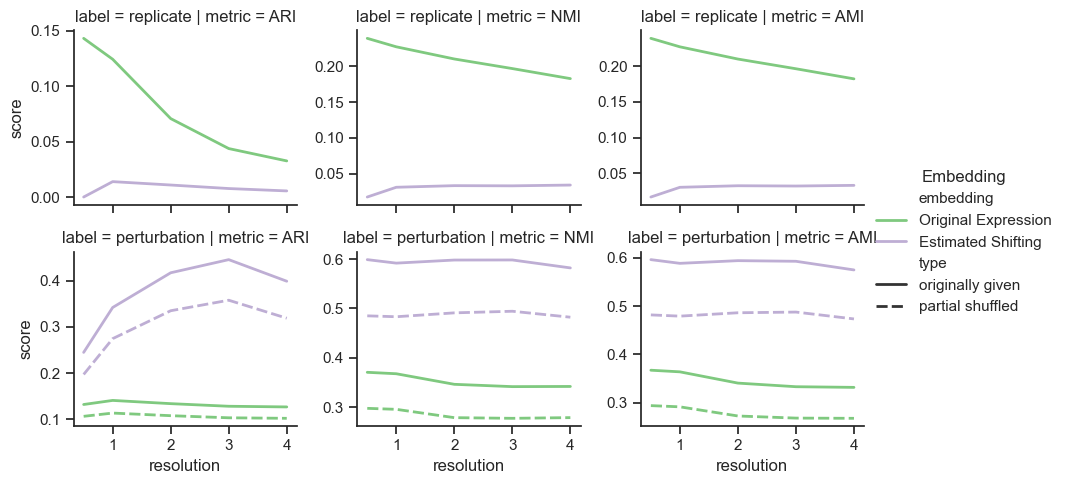

In [14]:

plot_df = cluster_quality_id.melt(
    id_vars=['resolution', 'label', 'embedding', 'type'],
    value_vars=['ARI', 'NMI', 'AMI'],
    var_name='metric',
    value_name='score',
)

g = sns.relplot(
    data=plot_df, 
    x='resolution', y='score', hue='embedding', style='type',
    row='label',
    col='metric',
    kind='line', 
    facet_kws=dict(sharey=False),
    height=2.5, aspect=1.2,
    legend='auto',
    linewidth=2,
    palette=sns.color_palette('Accent', 2),
)
g.legend.set_title('Embedding')
g.figure.savefig('../figures/5_kowalski_noisy_cluster_quality_id.pdf', bbox_inches='tight')
g.figure.show()

In [15]:
pert_id = pert_id[pert_id.obsm['X_umap'][:, 0] < pert_id.obsm['X_umap'][:, 0].max()-0.1].copy()

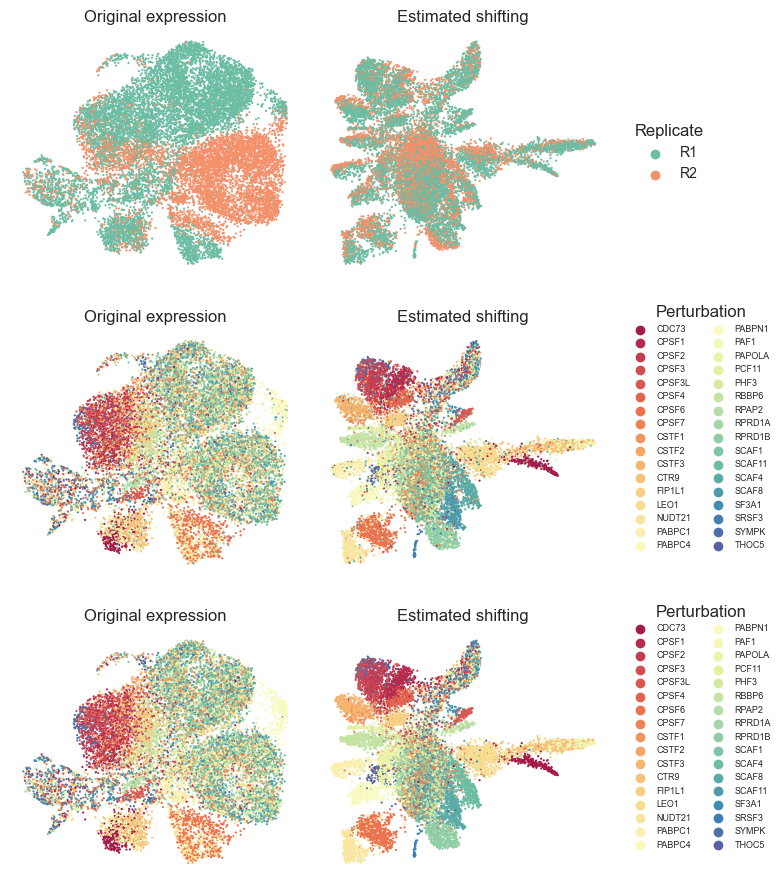

In [16]:
fig = plt.figure(figsize=(8, 9))
gs = GridSpec(3, 2,  figure=fig)
axes = []

# batch before modeling
ax1 = fig.add_subplot(gs[0, 0])
axes.append(ax1)
sc.pl.umap(
    pert_id, color='replicate', ax=ax1, 
    show=False, frameon=False,
    palette=sns.color_palette('Set2', desat=0.9),
    size=10,
)
ax1.set_title('Original expression')
ax1.legend().remove()
ax1.collections[0].set_rasterized(True)

# batch after modeling
ax2 = fig.add_subplot(gs[0, 1])
axes.append(ax2)
sc.pl.umap(
    shift_id, color='replicate', ax=ax2, 
    show=False, frameon=False,
    palette=sns.color_palette('Set2', desat=0.9),
    size=10,
)
ax2.set_title('Estimated shifting')
ax2.legend().remove()
ax2.collections[0].set_rasterized(True)

legend_ax = fig.add_subplot(gs[0,-1])
legend_ax.axis('off')
handles, labels = ax2.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    fontsize=10,
    title='Replicate',
)


color_list = list(sns.color_palette('Spectral', n_colors=len(order), desat=0.9).as_hex())
# pert before modeling
ax3 = fig.add_subplot(gs[1, 0])
axes.append(ax3)
sc.pl.umap(
    pert_id, color='perturbation', ax=ax3, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax3.set_title('Original expression')
ax3.legend().remove()
ax3.collections[0].set_rasterized(True)

# pert after modeling
ax4 = fig.add_subplot(gs[1, 1])
axes.append(ax4)
sc.pl.umap(
    shift_id, color='perturbation', ax=ax4, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax4.set_title('Estimated shifting')
ax4.legend().remove()
ax4.collections[0].set_rasterized(True)
legend_ax = fig.add_subplot(gs[1,-1])
legend_ax.axis('off')
handles, labels = ax4.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.6),
    fontsize=6.5,
    title='Perturbation',
    frameon=False,
    ncol=2,
)

ax5 = fig.add_subplot(gs[2, 0])
axes.append(ax5)
sc.pl.umap(
    pert_id, color='perturbation_true', ax=ax5, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax5.set_title('Original expression')
ax5.legend().remove()
ax5.collections[0].set_rasterized(True)

# pert after modeling
ax6 = fig.add_subplot(gs[2, 1])
axes.append(ax6)
sc.pl.umap(
    shift_id, color='perturbation_true', ax=ax6, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax6.set_title('Estimated shifting')
ax6.legend().remove()
ax6.collections[0].set_rasterized(True)
legend_ax = fig.add_subplot(gs[2,-1])
legend_ax.axis('off')
handles, labels = ax6.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.6),
    fontsize=6.5,
    title='Perturbation',
    frameon=False,
    ncol=2,
)

fig.subplots_adjust(top=0.95)
plt.tight_layout()
plt.savefig('../figures/5_kowalski_noisy_umap_id_batch_pert.pdf', bbox_inches='tight', dpi=600)
plt.show()

In [17]:
# OOD setting
pert_ood = ad[ad.obs['Group'] == 'OOD'].copy()
pert_ood.obs['perturbation'] = pd.Categorical(pert_ood.obs['perturbation'], categories=order, ordered=True)
shift_ood = sc.AnnData(
    X=pert_ood.obsm['shift'],
    obs=pert_ood.obs,
    obsm={'proba': pert_ood.obsm['proba']},
    var=pd.DataFrame(index=[f's{i}' for i in range(pert_ood.obsm['shift'].shape[1])])
)
sc.pp.pca(shift_ood)
sc.pp.neighbors(shift_ood)
sc.tl.umap(shift_ood)

In [18]:
cluster_quality_ood = pd.concat([
    calculate_cluster_quality(pert_ood).assign(embedding='Original Expression'), 
    calculate_cluster_quality(shift_ood).assign(embedding='Estimated Shifting')
])

In [19]:
cluster_quality_ood['type'] = cluster_quality_ood['label'].map({
    'replicate': 'originally given',
    'perturbation': 'partial shuffled',
    'perturbation_true': 'originally given'
})
cluster_quality_ood['label'] = cluster_quality_ood['label'].map({
    'replicate': 'replicate',
    'perturbation': 'perturbation',
    'perturbation_true': 'perturbation'
})
cluster_quality_ood

,resolution,label,ARI,NMI,AMI,embedding,type
0,0.5,replicate,0.179576,0.297699,0.297453,Original Expression,originally given
1,0.5,perturbation,0.054536,0.187684,0.182806,Original Expression,partial shuffled
2,0.5,perturbation,0.065814,0.234900,0.230313,Original Expression,originally given
3,1.0,replicate,0.161354,0.310135,0.309804,Original Expression,originally given
4,1.0,perturbation,0.055985,0.212104,0.205193,Original Expression,partial shuffled
5,1.0,perturbation,0.067675,0.262101,0.255640,Original Expression,originally given
6,2.0,replicate,0.073570,0.240828,0.240231,Original Expression,originally given
7,2.0,perturbation,0.072547,0.244643,0.232499,Original Expression,partial shuffled
8,2.0,perturbation,0.089075,0.297278,0.286000,Original Expression,originally given
9,3.0,replicate,0.049990,0.232848,0.232063,Original Expression,originally given


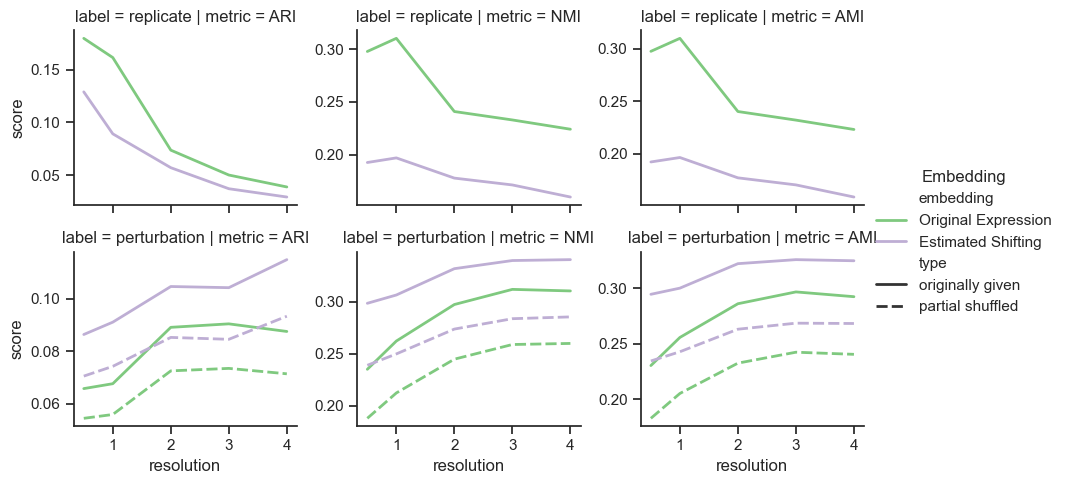

In [20]:

plot_df = cluster_quality_ood.melt(
    id_vars=['resolution', 'label', 'embedding', 'type'],
    value_vars=['ARI', 'NMI', 'AMI'],
    var_name='metric',
    value_name='score',
)

g = sns.relplot(
    data=plot_df, 
    x='resolution', y='score', hue='embedding', style='type',
    row='label',
    col='metric',
    kind='line', 
    facet_kws=dict(sharey=False),
    height=2.5, aspect=1.2,
    legend='auto',
    linewidth=2,
    palette=sns.color_palette('Accent', 2),
)
g.legend.set_title('Embedding')
g.figure.savefig('../figures/5_kowalski_noisy_cluster_quality_ood.pdf', bbox_inches='tight')
g.figure.show()

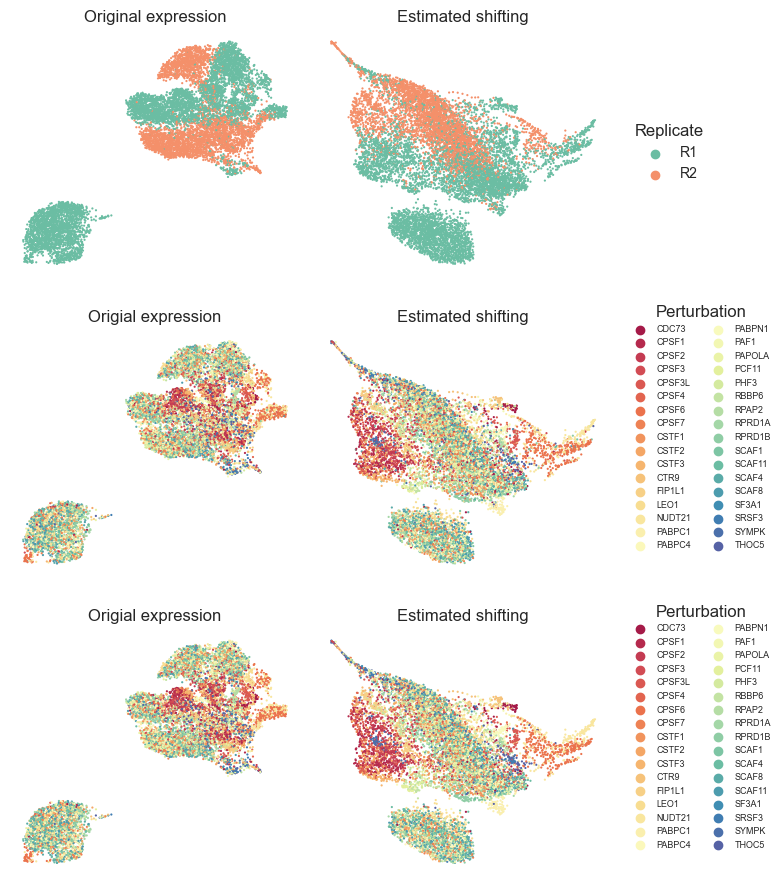

In [21]:
fig = plt.figure(figsize=(8, 9))
gs = GridSpec(3, 2,  figure=fig)
axes = []

# batch before modeling
ax1 = fig.add_subplot(gs[0, 0])
axes.append(ax1)
sc.pl.umap(
    pert_ood, color='replicate', ax=ax1, 
    show=False, frameon=False,
    palette=sns.color_palette('Set2', desat=0.9),
    size=10,
)
ax1.set_title('Original expression')
ax1.legend().remove()
ax1.collections[0].set_rasterized(True)

# batch after modeling
ax2 = fig.add_subplot(gs[0, 1])
axes.append(ax2)
sc.pl.umap(
    shift_ood, color='replicate', ax=ax2, 
    show=False, frameon=False,
    palette=sns.color_palette('Set2', desat=0.9),
    size=10,
)
ax2.set_title('Estimated shifting')
ax2.legend().remove()
ax2.collections[0].set_rasterized(True)

legend_ax = fig.add_subplot(gs[0,-1])
legend_ax.axis('off')
handles, labels = ax2.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5),
    frameon=False,
    fontsize=10,
    title='Replicate',
)


color_list = list(sns.color_palette('Spectral', n_colors=len(order), desat=0.9).as_hex())
# pert before modeling
ax3 = fig.add_subplot(gs[1, 0])
axes.append(ax3)
sc.pl.umap(
    pert_ood, color='perturbation', ax=ax3, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax3.set_title('Origial expression')
ax3.legend().remove()
ax3.collections[0].set_rasterized(True)

# pert after modeling
ax4 = fig.add_subplot(gs[1, 1])
axes.append(ax4)
sc.pl.umap(
    shift_ood, color='perturbation', ax=ax4, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax4.set_title('Estimated shifting')
ax4.legend().remove()
ax4.collections[0].set_rasterized(True)
legend_ax = fig.add_subplot(gs[1,-1])
legend_ax.axis('off')
handles, labels = ax4.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.6),
    fontsize=6.5,
    title='Perturbation',
    frameon=False,
    ncol=2,
)

# pert before modeling
ax5 = fig.add_subplot(gs[2, 0])
axes.append(ax5)
sc.pl.umap(
    pert_ood, color='perturbation_true', ax=ax5, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax5.set_title('Origial expression')
ax5.legend().remove()
ax5.collections[0].set_rasterized(True)

# pert after modeling
ax6 = fig.add_subplot(gs[2, 1])
axes.append(ax6)
sc.pl.umap(
    shift_ood, color='perturbation_true', ax=ax6, 
    show=False, frameon=False, 
    palette=color_list,
    size=10,
)
ax6.set_title('Estimated shifting')
ax6.legend().remove()
ax6.collections[0].set_rasterized(True)
legend_ax = fig.add_subplot(gs[2,-1])
legend_ax.axis('off')
handles, labels = ax6.get_legend_handles_labels()
legend_ax.legend(
    handles, labels, 
    loc='center left', 
    bbox_to_anchor=(1.05, 0.6),
    fontsize=6.5,
    title='Perturbation',
    frameon=False,
    ncol=2,
)
fig.subplots_adjust(top=0.95)
plt.tight_layout()
plt.savefig('../figures/5_kowalski_noisy_umap_ood_batch_pert.pdf', bbox_inches='tight', dpi=600)
plt.show()